**Import Library, Mount Google Drive, dan Setup Device**

In [6]:
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/Tugas_DeepLearning', exist_ok=True)

# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Menggunakan device: cuda


**Data Preprocessing & Loading (CIFAR-10)**

In [8]:
# Tambahan augmentasi pada data training
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
        ),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
        ),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2
)

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

print(f"Jumlah data training (latih): {len(trainset)} sampel")
print(f"Jumlah data testing (uji): {len(testset)} sampel")
print(f"Total keseluruhan data: {len(trainset) + len(testset)} sampel")
print(f"Jumlah kelas objek: {len(classes)} kelas ({classes})")

Jumlah data training (latih): 50000 sampel
Jumlah data testing (uji): 10000 sampel
Total keseluruhan data: 60000 sampel
Jumlah kelas objek: 10 kelas (('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'))


**Definisi Arsitektur Model A, Model B, dan Fungsi Parameter**

In [9]:
# Model A (Custom CNN 3 Blok)
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Model B (Mini-ResNet dengan Residual Block)
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return self.relu(out)

class MiniResNet(nn.Module):
    def __init__(self):
        super(MiniResNet, self).__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.res_block1 = ResidualBlock(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.res_block2 = ResidualBlock(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.init_conv(x)
        x = self.pool1(self.res_block1(x))
        x = self.pool2(self.res_block2(x))
        x = self.classifier(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_a = CustomCNN().to(device)
model_b = MiniResNet().to(device)

print(f"Total Parameter Model A: {count_parameters(model_a):,}")
print(f"Total Parameter Model B: {count_parameters(model_b):,}")

Total Parameter Model A: 620,810
Total Parameter Model B: 150,474


**Fungsi Training & Evaluasi**

In [10]:
def train_and_evaluate(model, model_name, epochs=25):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=0.001)

  # Perbaikan: Hapus argumen verbose=True
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode="min", factor=0.5, patience=3
  )

  history = {
      "train_loss": [],
      "train_acc": [],
      "val_loss": [],
      "val_acc": [],
  }
  start_time = time.time()

  for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in trainloader:
      inputs, labels = inputs.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * inputs.size(0)
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
      for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        val_total += labels.size(0)
        val_correct += predicted.eq(labels).sum().item()

    v_loss = val_loss / val_total
    v_acc = val_correct / val_total

    scheduler.step(v_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    print(
        f"[{model_name}] Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}"
        f" Acc: {train_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}"
    )

  total_time = time.time() - start_time
  print(f"[{model_name}] Waktu Training Total: {total_time:.2f} detik")
  return history, total_time

**Eksekusi Training untuk Model A & Model B**

In [11]:
print("--- Training Model A ---")
history_a, time_a = train_and_evaluate(model_a, "Model A", epochs=25)

print("\n--- Training Model B ---")
history_b, time_b = train_and_evaluate(model_b, "Model B", epochs=25)

--- Training Model A ---
[Model A] Epoch 1/25 | Train Loss: 1.5861 Acc: 0.4148 | Val Loss: 1.2652 Acc: 0.5488
[Model A] Epoch 2/25 | Train Loss: 1.2799 Acc: 0.5399 | Val Loss: 0.9940 Acc: 0.6428
[Model A] Epoch 3/25 | Train Loss: 1.1461 Acc: 0.5924 | Val Loss: 0.9365 Acc: 0.6624
[Model A] Epoch 4/25 | Train Loss: 1.0501 Acc: 0.6287 | Val Loss: 0.8946 Acc: 0.6835
[Model A] Epoch 5/25 | Train Loss: 0.9933 Acc: 0.6517 | Val Loss: 0.8086 Acc: 0.7152
[Model A] Epoch 6/25 | Train Loss: 0.9391 Acc: 0.6728 | Val Loss: 0.7654 Acc: 0.7269
[Model A] Epoch 7/25 | Train Loss: 0.9090 Acc: 0.6859 | Val Loss: 0.7402 Acc: 0.7405
[Model A] Epoch 8/25 | Train Loss: 0.8672 Acc: 0.7029 | Val Loss: 0.7186 Acc: 0.7438
[Model A] Epoch 9/25 | Train Loss: 0.8396 Acc: 0.7100 | Val Loss: 0.6699 Acc: 0.7648
[Model A] Epoch 10/25 | Train Loss: 0.8069 Acc: 0.7262 | Val Loss: 0.6849 Acc: 0.7612
[Model A] Epoch 11/25 | Train Loss: 0.7843 Acc: 0.7305 | Val Loss: 0.7198 Acc: 0.7468
[Model A] Epoch 12/25 | Train Loss: 0.

**Visualisasi Grafik Perbandingan Loss & Akurasi**

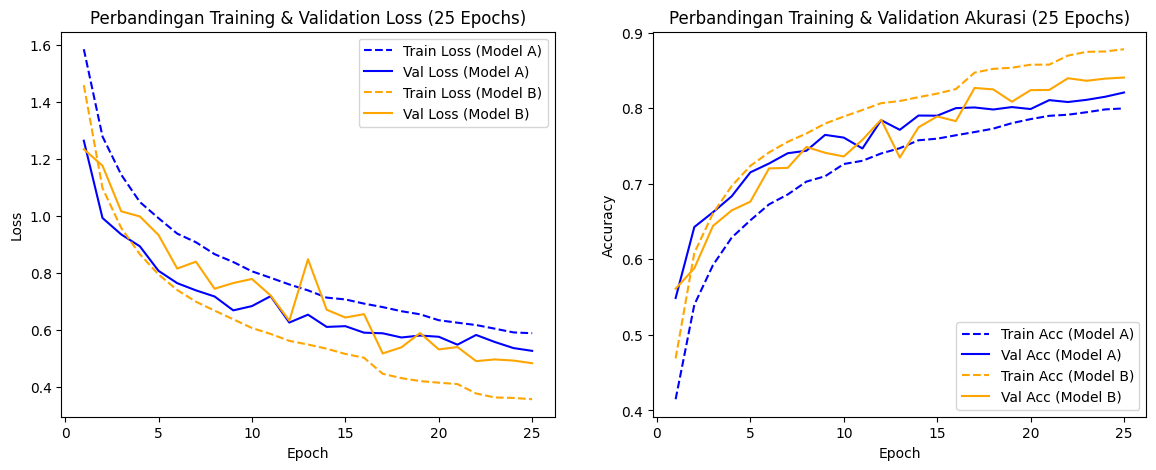

In [13]:
epochs_range = range(1, 26)
plt.figure(figsize=(14, 5))

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    history_a["train_loss"],
    label="Train Loss (Model A)",
    linestyle="--",
    color="blue",
)
plt.plot(
    epochs_range,
    history_a["val_loss"],
    label="Val Loss (Model A)",
    color="blue",
)
plt.plot(
    epochs_range,
    history_b["train_loss"],
    label="Train Loss (Model B)",
    linestyle="--",
    color="orange",
)
plt.plot(
    epochs_range,
    history_b["val_loss"],
    label="Val Loss (Model B)",
    color="orange",
)
plt.title("Perbandingan Training & Validation Loss (25 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Grafik Akurasi
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    history_a["train_acc"],
    label="Train Acc (Model A)",
    linestyle="--",
    color="blue",
)
plt.plot(
    epochs_range,
    history_a["val_acc"],
    label="Val Acc (Model A)",
    color="blue",
)
plt.plot(
    epochs_range,
    history_b["train_acc"],
    label="Train Acc (Model B)",
    linestyle="--",
    color="orange",
)
plt.plot(
    epochs_range,
    history_b["val_acc"],
    label="Val Acc (Model B)",
    color="orange",
)
plt.title("Perbandingan Training & Validation Akurasi (25 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Tugas_DeepLearning/grafik_perbandingan_model_v2.png"
)
plt.show()

**Evaluasi Akhir & Confusion Matrix**

--- Evaluasi Akhir Model A ---


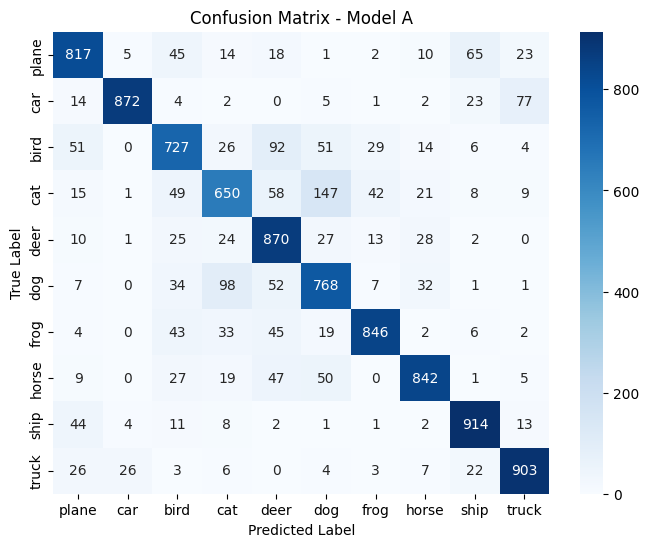


--- Evaluasi Akhir Model B ---


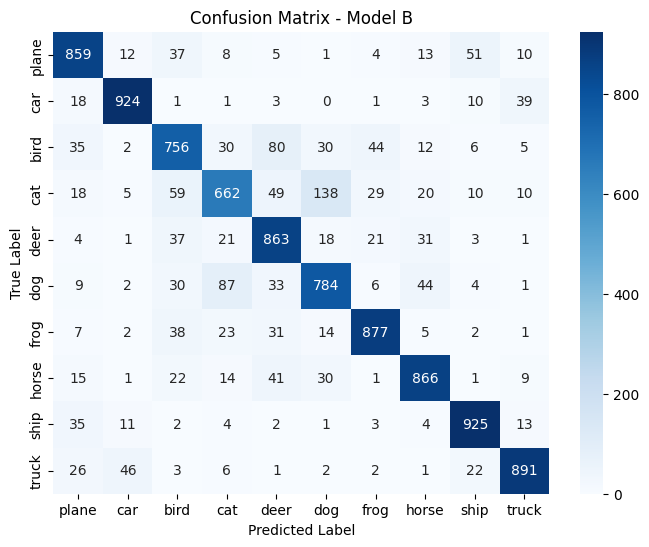


Semua grafik dan file model berhasil disimpan di Google Drive!


In [14]:
def evaluate_and_confusion_matrix(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(f'/content/drive/MyDrive/Tugas_DeepLearning/confusion_matrix_{model_name.lower().replace(" ", "_")}.png')
    plt.show()

print("--- Evaluasi Akhir Model A ---")
evaluate_and_confusion_matrix(model_a, "Model A")

print("\n--- Evaluasi Akhir Model B ---")
evaluate_and_confusion_matrix(model_b, "Model B")

# Simpan Bobot Model
torch.save(model_a.state_dict(), '/content/drive/MyDrive/Tugas_DeepLearning/model_a_cifar10.pth')
torch.save(model_b.state_dict(), '/content/drive/MyDrive/Tugas_DeepLearning/model_b_cifar10.pth')
print("\nSemua grafik dan file model berhasil disimpan di Google Drive!")

In [15]:
from sklearn.metrics import classification_report

def print_detailed_metrics(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"=== Classification Report untuk {model_name} ===")
    # target_names diisi dengan nama kelas CIFAR-10 agar laporannya mudah dibaca
    print(classification_report(all_labels, all_preds, target_names=classes))

# Jalankan untuk Model A dan Model B
print_detailed_metrics(model_a, "Model A")
print("\n" + "="*50 + "\n")
print_detailed_metrics(model_b, "Model B")

=== Classification Report untuk Model A ===
              precision    recall  f1-score   support

       plane       0.82      0.82      0.82      1000
         car       0.96      0.87      0.91      1000
        bird       0.75      0.73      0.74      1000
         cat       0.74      0.65      0.69      1000
        deer       0.73      0.87      0.80      1000
         dog       0.72      0.77      0.74      1000
        frog       0.90      0.85      0.87      1000
       horse       0.88      0.84      0.86      1000
        ship       0.87      0.91      0.89      1000
       truck       0.87      0.90      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



=== Classification Report untuk Model B ===
              precision    recall  f1-score   support

       plane       0.84      0.86      0.85      1000
         car       0.92      0.92      0.9